In [ ]:
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("../data/all_data_merged.csv", parse_dates=["DATE"])

df = df.sort_values(["DISTRICT","DATE"])

district_groups = {d: g.reset_index(drop=True) for d, g in df.groupby("DISTRICT")}

print(f"Number of districts: {len(district_groups)}")
print(f"Districts: {list(district_groups.keys())}")
print(f"First district:\n{district_groups[1].head()}")
print("shape:", district_groups[1].shape)

Saving all_data_merged.csv to all_data_merged (2).csv
File 'all_data_merged (2).csv' uploaded and read into a pandas DataFrame.
Number of districts: 37
Districts: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
First district:
        DATE  DISTRICT  WEATHER_CONDITION  SPECIAL_DAY  DAY_OF_WEEK_NUM  \
0 2024-01-01         1                  1            1                1   
1 2024-01-03         1                  2            0                3   
2 2024-01-04         1                  2            0                4   
3 2024-01-05         1                  2            0                5   
4 2024-01-06         1                  1            0                6   

   POPULATION  RAILWAY_STATIONS  BUS_STATIONS  CONGESTION  
0      344868                 5           678       0.213  
1      344868                 5           678       0.243  
2      344868                 5           678     

## Training Data Creator

In [ ]:
def make_sequences(group, seq_len=10):
    X_raw = group[["WEATHER_CONDITION","SPECIAL_DAY","DAY_OF_WEEK_NUM","POPULATION","RAILWAY_STATIONS","BUS_STATIONS"]].values
    y_raw = group["CONGESTION"].values.reshape(-1,1)

    sx, sy = MinMaxScaler(), MinMaxScaler()
    Xs, ys = sx.fit_transform(X_raw), sy.fit_transform(y_raw)

    Xs_seq, ys_seq = [],[]
    for i in range(len(Xs) - seq_len):
        Xs_seq.append(Xs[i: i+seq_len])
        ys_seq.append(ys[i+seq_len])
    return np.array(Xs_seq), np.array(ys_seq), sy

## LSTM Necessities

In [ ]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_dim= 32, n_layers = 1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h[:,-1,:])

In [29]:
def flatten_weights(model):
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters()])

def unflatten_weights(model, vec):
    idx = 0
    for p in model.parameters():
        numel = p.numel()
        chunk = vec[idx:idx+numel].reshape(p.shape)
        p.data.copy_(torch.from_numpy(chunk))
        idx += numel

In [ ]:
def make_fitness(X_train, y_train, device="cpu"):
    model = LSTMRegressor(n_features=X_train.shape[-1]).to(device)
    dim = sum(p.numel() for p in model.parameters())

    def fitness(pop):
        losses = []
        criterion = nn.MSELoss()
        Xb = torch.tensor(X_train, dtype=torch.float32).to(device)
        yb = torch.tensor(y_train, dtype=torch.float32).to(device)
        for particle in pop:
            unflatten_weights(model, particle)
            preds = model(Xb).squeeze()
            loss = criterion(preds, yb.squeeze()).item()
            losses.append(loss)
        return np.array(losses)

    return fitness, dim, model

## Hybrid PSO Optimization - Function with Experimental Setup

In [ ]:
def flatten_gradients(model):
    return np.concatenate([
        p.grad.detach().cpu().numpy().ravel()
        for p in model.parameters()
    ])

# Each experiment have an option to use it or not, as well as their parameters to change in function calls
# The experiments are grad_momentum, particle_momentum, decreasing_inertia, decreasing_learning_rate, once_in_x_grad_updates
def hybrid_pso_optimize(
    model,
    X_train, y_train,
    dim,
    n_particles=30,
    n_iters=100,
    w=0.9,
    c1=0.5,
    c2=0.3,
    alpha=0.01,
    grad_momentum=False,
    beta1=0.6,
    particle_momentum=False,
    beta2=0.6,
    decreasing_inertia=False,
    w_min=0.4,
    w_max=0.9,
    decreasing_learning_rate=False,
    once_in_x_grad_updates=1,
    bounds=None,
    verbose=True
):
    criterion = nn.MSELoss()

    if bounds is not None:
        low, high = bounds
        pos = np.random.uniform(low, high, (n_particles, dim))
    else:
        pos = np.random.randn(n_particles, dim)*0.1
    vel = np.zeros_like(pos)

    def eval_fitness(pop):
        out = []
        for p in pop:
            unflatten_weights(model, p)
            with torch.no_grad():
                preds = model(X_train).squeeze()
            loss = criterion(preds, y_train.squeeze()).item()
            out.append(loss)
        return np.array(out)

    fitness = eval_fitness(pos)
    pbest_pos   = pos.copy()
    pbest_score = fitness.copy()
    gidx        = np.argmin(pbest_score)
    gbest_pos   = pbest_pos[gidx].copy()
    gbest_score = pbest_score[gidx]

    grad_mom = np.zeros_like(pos)

    for it in range(1, n_iters+1):
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)

        # We compute the gradients every once_in_x_grad_updates iterations
        if (it % once_in_x_grad_updates) == 0:
            grads = []
            for p in pos:
                unflatten_weights(model, p)
                model.zero_grad()
                preds = model(X_train).squeeze()
                loss  = criterion(preds, y_train.squeeze())
                loss.backward()
                grads.append(flatten_gradients(model))
            grads = np.array(grads)

            # if the gradient momentum experiment is open, we use the previous values of momentum as well
            grad_mom = beta1 * grad_mom + (1 - beta1) * grads if grad_momentum else grads
        # if decreasing inertia is enabled, we decrease the inertia weight w towards the end of iterations
        w = w_max - (w_max - w_min) * (it / n_iters) if decreasing_inertia else w
        # if decreasing learning rate is enabled, we decrease the alpha value towards the end of iterations
        alpha = alpha * (1 - it / n_iters) if decreasing_learning_rate else alpha

        new_wel = (
            w * vel
            + c1 * r1 * (pbest_pos - pos)
            + c2 * r2 * (gbest_pos - pos)
            - ((alpha * grad_mom) if (it % once_in_x_grad_updates == 0) else 0)
        )

        # if particle momentum is enabled, we apply the momentum to the velocity calculated alltogether
        vel = beta2 * vel + (1 - beta2) * new_wel if particle_momentum else new_wel

        pos = pos + vel
        if bounds is not None:
            pos = np.clip(pos, low, high)

        fitness = eval_fitness(pos)

        # Personal & Global best calculations
        better = fitness < pbest_score
        pbest_pos[better]   = pos[better]
        pbest_score[better] = fitness[better]

        idx = np.argmin(pbest_score)
        if pbest_score[idx] < gbest_score:
            gbest_score = pbest_score[idx]
            gbest_pos   = pbest_pos[idx].copy()

        if verbose and it % 10 == 0:
            print(f"Iter {it:3d}/{n_iters}, gbest MSE = {gbest_score:.6f}")

    return gbest_score, gbest_pos

## Hybrid PSO Optimization - with each experiment

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx   = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32, device=device)
yb_train = torch.tensor(y_train_all, dtype=torch.float32, device=device)

results_hybrid = {}

# Running 5 of the experiments and saving the results
for i in range(6):
    model = LSTMRegressor(n_features=X_train_all.shape[-1]).to(device)
    dim = sum(p.numel() for p in model.parameters())

    grad_momentum = (i == 1 or i == 5)
    particle_momentum = (i == 2 or i == 5)
    decreasing_inertia = (i == 3 or i == 5)
    decreasing_learning_rate = (i == 4 or i == 5)

    start_time = time.time()
    best_cost, best_pos = hybrid_pso_optimize(
        model, Xb_train, yb_train, dim,
        n_particles=30,
        n_iters=100,
        w=0.9, c1=0.5, c2=0.3, alpha=0.01,
        grad_momentum=grad_momentum,
        particle_momentum=particle_momentum,
        decreasing_inertia=decreasing_inertia,
        decreasing_learning_rate=decreasing_learning_rate,
        bounds=(-1,1),
        verbose=True
    )
    unflatten_weights(model, best_pos)
    elapsed = time.time() - start_time
    print(f"[run {i}] Training completed in {elapsed:.3f}s, train MSE={best_cost:.6f}")

    exp_results = {}
    model.eval()
    with torch.no_grad():
        for d, (X_test, y_test, scaler) in test_splits.items():
            Xb_test = torch.tensor(X_test, dtype=torch.float32, device=device)
            y_pred_scaled = model(Xb_test).cpu().numpy()
            y_pred = scaler.inverse_transform(y_pred_scaled)
            y_true = scaler.inverse_transform(y_test)
            test_mse = ((y_pred - y_true)**2).mean()

            exp_results[d] = {
                "model": model,
                "scaler": scaler,
                "train_mse": best_cost,
                "test_mse": test_mse
            }

    results_hybrid[i] = exp_results

KeyboardInterrupt: 

## Visualization of Results

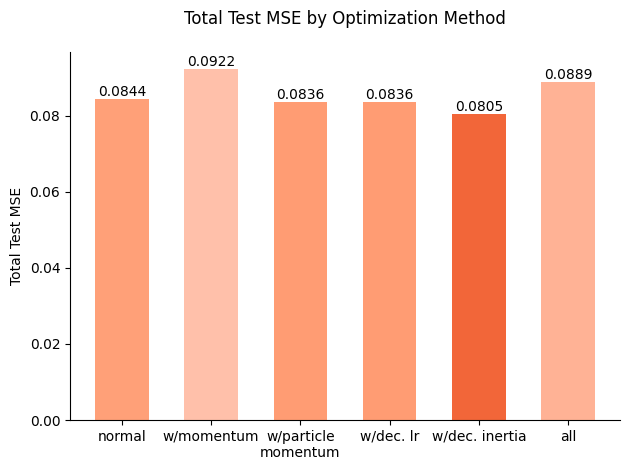

In [ ]:
total_psograd_normal = sum(results_hybrid[0][d]['test_mse'] for d in results_hybrid[0])
total_psograd_momentum = sum(results_hybrid[1][d]['test_mse'] for d in results_hybrid[1])
total_psograd_particle_momentum = sum(results_hybrid[2][d]['test_mse'] for d in results_hybrid[2])
total_psograd_dec_inertia = sum(results_hybrid[3][d]['test_mse'] for d in results_hybrid[3])
total_psograd_dec_lr = sum(results_hybrid[4][d]['test_mse'] for d in results_hybrid[4])
total_psograd_all = sum(results_hybrid[5][d]['test_mse'] for d in results_hybrid[5])

methods = ['normal', 'w/momentum', 'w/particle\nmomentum', 'w/dec. lr', 'w/dec. inertia', 'all']
values  = [total_psograd_normal, total_psograd_momentum, total_psograd_particle_momentum, total_psograd_dec_lr, total_psograd_dec_inertia, total_psograd_all]

min_value = min(values)
max_value = max(values)
colors = []

# To have a gradient effect we have used a simple linear interpolation between two colors
for value in values:
    weight = (value - min_value) / (max_value - min_value)
    r = int(255 * (1 - weight) + 255 * weight)
    g = int(144 * (1 - weight) + 192 * weight)
    b = int(96 * (1 - weight) + 170 * weight)
    colors.append(f"#{r:02x}{g:02x}{b:02x}")

plt.figure()
bars = plt.bar(methods, values, color=colors, width=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('Total Test MSE')

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.title('Total Test MSE by Optimization Method', pad=20)
plt.tight_layout()
plt.show()

## Hybrid PSO Optimization - with "once in X round experiment"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx   = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32, device=device)
yb_train = torch.tensor(y_train_all, dtype=torch.float32, device=device)

round_results_hybrid = {}

# Running 5 of the experiments with once_in_x_grad_updates and saving the results
for i in range(1,6):
    model = LSTMRegressor(n_features=X_train_all.shape[-1]).to(device)
    dim = sum(p.numel() for p in model.parameters())

    start_time = time.time()
    best_cost, best_pos = hybrid_pso_optimize(
        model, Xb_train, yb_train, dim,
        n_particles=30,
        n_iters=100,
        w=0.9, c1=0.5, c2=0.3, alpha=0.01,
        once_in_x_grad_updates=i,
        bounds=(-1,1),
        verbose=True
    )
    unflatten_weights(model, best_pos)
    elapsed = time.time() - start_time
    print(f"[run {i}] Training completed in {elapsed:.3f}s, train MSE={best_cost:.6f}")

    exp_results = {}
    model.eval()
    with torch.no_grad():
        for d, (X_test, y_test, scaler) in test_splits.items():
            Xb_test = torch.tensor(X_test, dtype=torch.float32, device=device)
            y_pred_scaled = model(Xb_test).cpu().numpy()
            y_pred = scaler.inverse_transform(y_pred_scaled)
            y_true = scaler.inverse_transform(y_test)
            test_mse = ((y_pred - y_true)**2).mean()

            exp_results[d] = {
                "model": model,
                "scaler": scaler,
                "train_mse": best_cost,
                "test_mse": test_mse,
                "train_time": elapsed
            }

    round_results_hybrid[i] = exp_results

Iter  10/100, gbest MSE = 0.035940
Iter  20/100, gbest MSE = 0.026930
Iter  30/100, gbest MSE = 0.026588
Iter  40/100, gbest MSE = 0.025558
Iter  50/100, gbest MSE = 0.024467
Iter  60/100, gbest MSE = 0.024396
Iter  70/100, gbest MSE = 0.024227
Iter  80/100, gbest MSE = 0.024084
Iter  90/100, gbest MSE = 0.023999
Iter 100/100, gbest MSE = 0.023989
[run 1] Training completed in 28.960s, train MSE=0.023989
Iter  10/100, gbest MSE = 0.032683
Iter  20/100, gbest MSE = 0.027859
Iter  30/100, gbest MSE = 0.025873
Iter  40/100, gbest MSE = 0.025144
Iter  50/100, gbest MSE = 0.024983
Iter  60/100, gbest MSE = 0.024887
Iter  70/100, gbest MSE = 0.024602
Iter  80/100, gbest MSE = 0.024483
Iter  90/100, gbest MSE = 0.024392
Iter 100/100, gbest MSE = 0.024300
[run 2] Training completed in 19.118s, train MSE=0.024300
Iter  10/100, gbest MSE = 0.031760
Iter  20/100, gbest MSE = 0.026770
Iter  30/100, gbest MSE = 0.025915
Iter  40/100, gbest MSE = 0.025107
Iter  50/100, gbest MSE = 0.024986
Iter  60/

## Visualization of Results

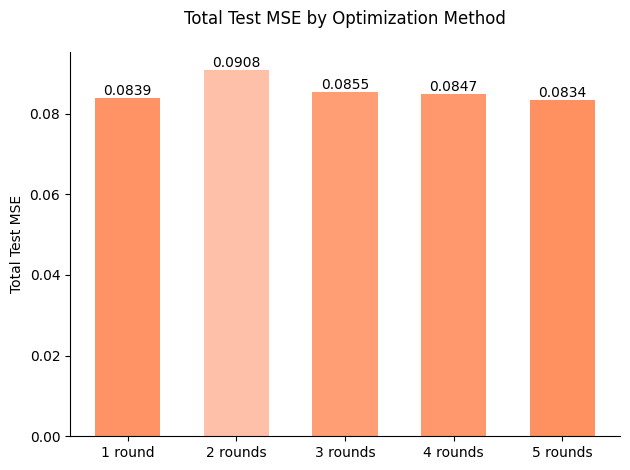

In [ ]:
total_psograd_normal_1_round = sum(round_results_hybrid[1][d]['test_mse'] for d in round_results_hybrid[1])
total_psograd_normal_2_round = sum(round_results_hybrid[2][d]['test_mse'] for d in round_results_hybrid[2])
total_psograd_normal_3_round = sum(round_results_hybrid[3][d]['test_mse'] for d in round_results_hybrid[3])
total_psograd_normal_4_round = sum(round_results_hybrid[4][d]['test_mse'] for d in round_results_hybrid[4])
total_psograd_normal_5_round = sum(round_results_hybrid[5][d]['test_mse'] for d in round_results_hybrid[5])

methods = ['1 round', '2 rounds', '3 rounds', '4 rounds', '5 rounds']
values  = [total_psograd_normal_1_round, total_psograd_normal_2_round, total_psograd_normal_3_round, total_psograd_normal_4_round, total_psograd_normal_5_round]

min_value = min(values)
max_value = max(values)
colors = []
for value in values:
    weight = (value - min_value) / (max_value - min_value)
    r = int(255 * (1 - weight) + 255 * weight)
    g = int(144 * (1 - weight) + 192 * weight)
    b = int(96 * (1 - weight) + 170 * weight)
    colors.append(f"#{r:02x}{g:02x}{b:02x}")

plt.figure()
bars = plt.bar(methods, values, color=colors, width=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('Total Test MSE')

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.title('Total Test MSE by Optimization Method', pad=20)
plt.tight_layout()
plt.show()

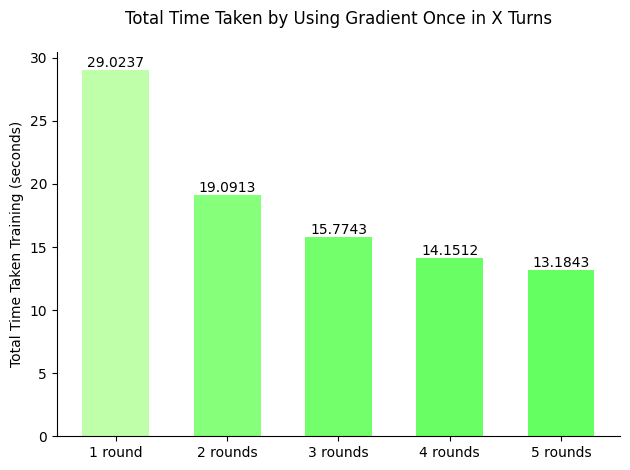

In [ ]:
total_psograd_normal_1_round = sum(round_results_hybrid[1][d]['train_time'] for d in round_results_hybrid[1])
total_psograd_normal_2_round = sum(round_results_hybrid[2][d]['train_time'] for d in round_results_hybrid[2])
total_psograd_normal_3_round = sum(round_results_hybrid[3][d]['train_time'] for d in round_results_hybrid[3])
total_psograd_normal_4_round = sum(round_results_hybrid[4][d]['train_time'] for d in round_results_hybrid[4])
total_psograd_normal_5_round = sum(round_results_hybrid[5][d]['train_time'] for d in round_results_hybrid[5])

methods = ['1 round', '2 rounds', '3 rounds', '4 rounds', '5 rounds']
values  = [total_psograd_normal_1_round, total_psograd_normal_2_round, total_psograd_normal_3_round, total_psograd_normal_4_round, total_psograd_normal_5_round]
values = [t / len(district_groups) for t in values]

min_value = min(values)
max_value = max(values)
colors = []
for value in values:
    weight = (value - min_value) / (max_value - min_value)
    r = int(100 * (1 - weight) + 192 * weight)
    g = int(255 * (1 - weight) + 255 * weight)
    b = int(96 * (1 - weight) + 170 * weight)
    colors.append(f"#{r:02x}{g:02x}{b:02x}")

plt.figure()
bars = plt.bar(methods, values, color=colors, width=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('Total Time Taken Training (seconds)')

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.title('Total Time Taken by Using Gradient Once in X Turns', pad=20)
plt.tight_layout()
plt.show()

## Hybrid PSO Optimization - with "once in X round experiment" from 1 round to 100

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx   = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32, device=device)
yb_train = torch.tensor(y_train_all, dtype=torch.float32, device=device)

round_results_hybrid = {}

# For all 100 runs, we will use the once_in_x_grad_updates parameter, it takes time...
for i in range(1,101):
    model = LSTMRegressor(n_features=X_train_all.shape[-1]).to(device)
    dim = sum(p.numel() for p in model.parameters())

    start_time = time.time()
    best_cost, best_pos = hybrid_pso_optimize(
        model, Xb_train, yb_train, dim,
        n_particles=30,
        n_iters=100,
        w=0.9, c1=0.5, c2=0.3, alpha=0.01,
        once_in_x_grad_updates=i,
        bounds=(-1,1),
        verbose=True
    )
    unflatten_weights(model, best_pos)
    elapsed = time.time() - start_time
    print(f"[run {i}] Training completed in {elapsed:.3f}s, train MSE={best_cost:.6f}")

    exp_results = {}
    model.eval()
    with torch.no_grad():
        for d, (X_test, y_test, scaler) in test_splits.items():
            Xb_test = torch.tensor(X_test, dtype=torch.float32, device=device)
            y_pred_scaled = model(Xb_test).cpu().numpy()
            y_pred = scaler.inverse_transform(y_pred_scaled)
            y_true = scaler.inverse_transform(y_test)
            test_mse = ((y_pred - y_true)**2).mean()

            exp_results[d] = {
                "model": model,
                "scaler": scaler,
                "train_mse": best_cost,
                "test_mse": test_mse,
                "train_time": elapsed
            }

    round_results_hybrid[i] = exp_results

Iter  10/100, gbest MSE = 0.029357
Iter  20/100, gbest MSE = 0.028739
Iter  30/100, gbest MSE = 0.027186
Iter  40/100, gbest MSE = 0.026225
Iter  50/100, gbest MSE = 0.025779
Iter  60/100, gbest MSE = 0.025129
Iter  70/100, gbest MSE = 0.024728
Iter  80/100, gbest MSE = 0.024295
Iter  90/100, gbest MSE = 0.023746
Iter 100/100, gbest MSE = 0.023534
[run 1] Training completed in 29.024s, train MSE=0.023534
Iter  10/100, gbest MSE = 0.031250
Iter  20/100, gbest MSE = 0.028770
Iter  30/100, gbest MSE = 0.027508
Iter  40/100, gbest MSE = 0.026507
Iter  50/100, gbest MSE = 0.025437
Iter  60/100, gbest MSE = 0.025238
Iter  70/100, gbest MSE = 0.025075
Iter  80/100, gbest MSE = 0.024859
Iter  90/100, gbest MSE = 0.024762
Iter 100/100, gbest MSE = 0.024611
[run 2] Training completed in 19.091s, train MSE=0.024611
Iter  10/100, gbest MSE = 0.035649
Iter  20/100, gbest MSE = 0.030710
Iter  30/100, gbest MSE = 0.026513
Iter  40/100, gbest MSE = 0.025115
Iter  50/100, gbest MSE = 0.024445
Iter  60/

## Visualization of Results

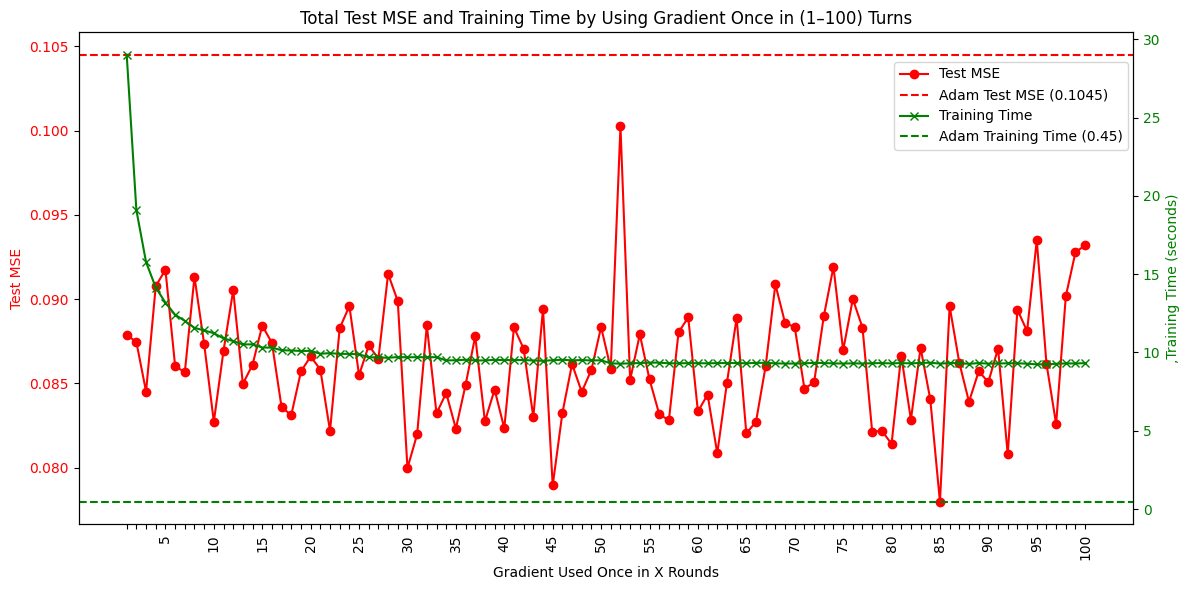

In [ ]:
total_psograd_normal_x_round = [sum(round_results_hybrid[i][d]['test_mse'] for d in round_results_hybrid[i]) for i in range(1, 101)]
total_time_psograd_normal_x_round = [sum(round_results_hybrid[i][d]['train_time'] for d in round_results_hybrid[i]) for i in range(1, 101)]

methods = [f"{i}" if (i % 5 == 0) else " " for i in range(1, 101)]
x = list(range(1, 101))
labels = [str(i) if i % 5 == 0 else "" for i in x]

mse_values = total_psograd_normal_x_round
time_values = [t / len(district_groups) for t in total_time_psograd_normal_x_round]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'red'
ax1.plot(x, mse_values, color=color1, label='Test MSE', marker='o')
ax1.axhline(y=0.1045, color='red', linestyle='--', linewidth=1.5, label='Adam Test MSE (0.1045)')
ax1.set_ylabel('Test MSE', color=color1)
ax1.set_xlabel('Gradient Used Once in X Rounds')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=90)

ax2 = ax1.twinx()
color2 = 'green'
ax2.plot(x, time_values, color=color2, label='Training Time', marker='x')
ax2.axhline(y=0.45, color='green', linestyle='--', linewidth=1.5, label='Adam Training Time (0.45)')
ax2.set_ylabel(',Training Time (seconds)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', bbox_to_anchor=(0.95, 0.9))

plt.title('Total Test MSE and Training Time by Using Gradient Once in (1-100) Turns')
fig.tight_layout()
plt.show()